# Plots generated by experiments

In [22]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [23]:
experiment_dir = '../experiments/'
N_values = [10, 25, 50, 100, 200, 499]


In [24]:

def plot_bps_per_p(all_results, p_values, N_values, n_trials=100):
    n_plots = len(p_values)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), dpi=150)
    if n_plots == 1:
        axes = [axes]

    for ax, p_true in zip(axes, p_values):
        means_lap = [all_results[p_true][N]['laplace'][0] for N in N_values]
        stds_lap  = [all_results[p_true][N]['laplace'][1] for N in N_values]
        means_tr  = [all_results[p_true][N]['transformer'][0] for N in N_values]
        stds_tr   = [all_results[p_true][N]['transformer'][1] for N in N_values]
        entropy   = all_results[p_true][N_values[0]]['entropy']

        # convert to standard error
        se_lap = [s / np.sqrt(n_trials) for s in stds_lap]
        se_tr  = [s / np.sqrt(n_trials) for s in stds_tr]

        ax.errorbar(N_values, means_lap, yerr=se_lap, fmt='o-', capsize=4, label='Laplace')
        ax.errorbar(N_values, means_tr,  yerr=se_tr,  fmt='s-', capsize=4, label='Transformer')
        ax.axhline(y=entropy, color='red', linestyle='--', label=f'Entropy ({entropy:.3f})')
        penalty = 0.5 * np.log2(np.array(N_values)) / np.array(N_values)
        ax.plot(N_values, entropy + penalty, 'g--', label='Entropy + USC penalty', linewidth=1)
        ax.set_xscale('log')
        ax.set_title(f'p={p_true}')
        ax.set_xlabel('N')
        ax.set_ylabel('BPS')
        ax.legend(fontsize=7)
        ax.grid(True)

    plt.suptitle('Laplace vs Transformer BPS convergence', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_gap(all_results, p_values, N_values):
    """Plot the gap (laplace BPS - transformer BPS) per p. Positive = transformer wins."""
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

    for p_true in p_values:
        gaps = [
            all_results[p_true][N]['laplace'][0] - all_results[p_true][N]['transformer'][0]
            for N in N_values
        ]
        ax.plot(N_values, gaps, marker='o', label=f'p={p_true}')

    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_xlabel('N')
    ax.set_ylabel('Laplace BPS - Transformer BPS')
    ax.set_title('Transformer advantage over Laplace (positive = transformer wins)')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [25]:
def load_experiment(file):
    with open(experiment_dir + file, 'rb') as f:
        return pickle.load(f)

{0.1: {10: {'laplace': (np.float64(0.6414795129434097), np.float64(0.2254065312965786)), 'transformer': (np.float64(0.640068243870586), np.float64(0.23671966880099737)), 'entropy': np.float64(0.4689955935892812)}, 25: {'laplace': (np.float64(0.5621635931760288), np.float64(0.1834603356472887)), 'transformer': (np.float64(0.563158072068217), np.float64(0.18727181284033853)), 'entropy': np.float64(0.4689955935892812)}, 50: {'laplace': (np.float64(0.5208559222497741), np.float64(0.1251423287899165)), 'transformer': (np.float64(0.5219558457074072), np.float64(0.12678083877604032)), 'entropy': np.float64(0.4689955935892812)}, 100: {'laplace': (np.float64(0.48372505995958853), np.float64(0.08637593132261365)), 'transformer': (np.float64(0.48367007863629113), np.float64(0.08823825340241254)), 'entropy': np.float64(0.4689955935892812)}, 200: {'laplace': (np.float64(0.4867555045614481), np.float64(0.07041906982722676)), 'transformer': (np.float64(0.48958035140742523), np.float64(0.0712032642270

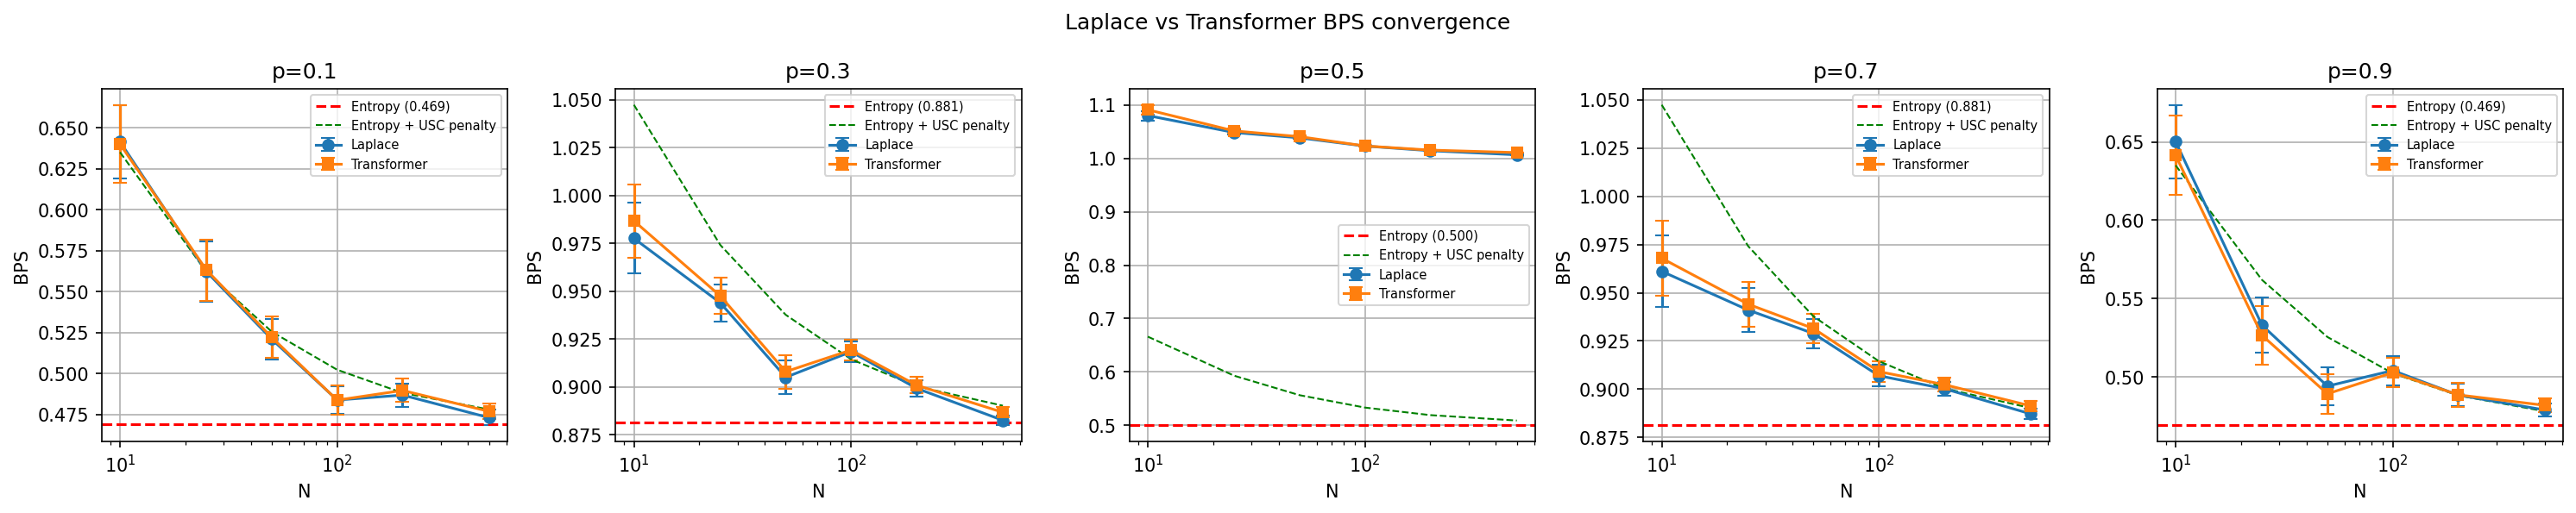

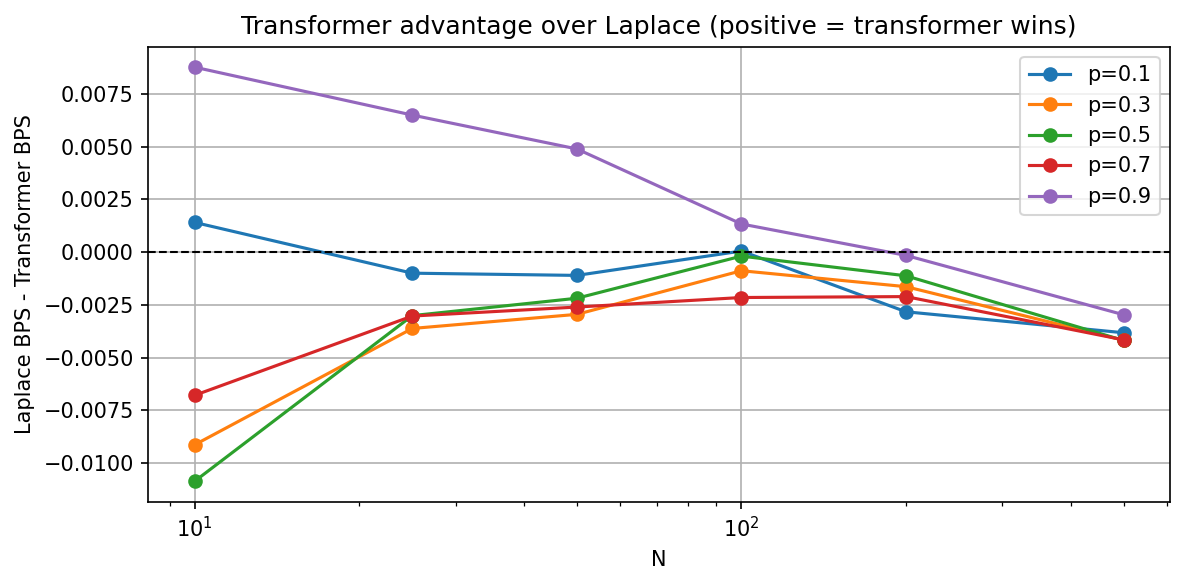

In [31]:
iid_results = load_experiment('iid_experiment.pkl')
print(iid_results)
N_values = sorted(next(iter(iid_results.values())).keys())
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
plot_bps_per_p(iid_results, p_values, N_values)
plot_gap(iid_results, p_values, N_values)

{0.3: {10: {'laplace': (np.float64(0.9582041561326488), np.float64(0.17847568973768901)), 'transformer': (np.float64(0.8834007723792863), np.float64(0.1703228795779635)), 'entropy': np.float64(0.8812908992306927)}, 25: {'laplace': (np.float64(0.9497079390257219), np.float64(0.09983804929343443)), 'transformer': (np.float64(0.891987993883632), np.float64(0.10524189964189043)), 'entropy': np.float64(0.8812908992306927)}, 50: {'laplace': (np.float64(0.9282785321028851), np.float64(0.07666226657621264)), 'transformer': (np.float64(0.8926591840591361), np.float64(0.07677618167988241)), 'entropy': np.float64(0.8812908992306927)}, 100: {'laplace': (np.float64(0.9067527759005714), np.float64(0.057924191890064)), 'transformer': (np.float64(0.8843039703676889), np.float64(0.05663846320307623)), 'entropy': np.float64(0.8812908992306927)}, 200: {'laplace': (np.float64(0.8995585216870227), np.float64(0.0344012834583583)), 'transformer': (np.float64(0.8848932455308094), np.float64(0.0345628458315711

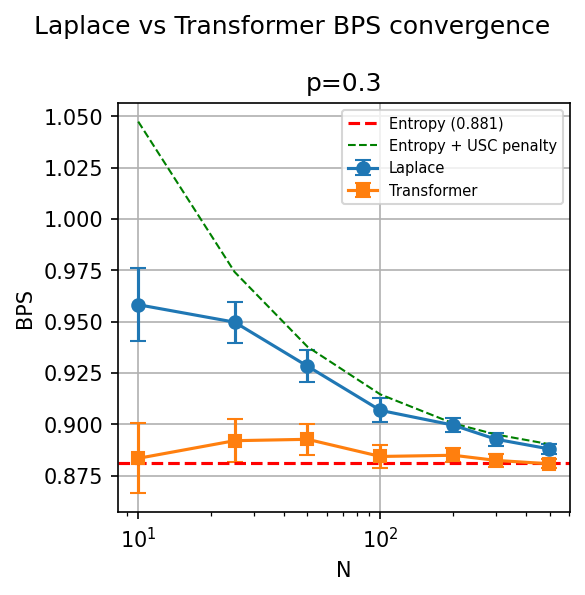

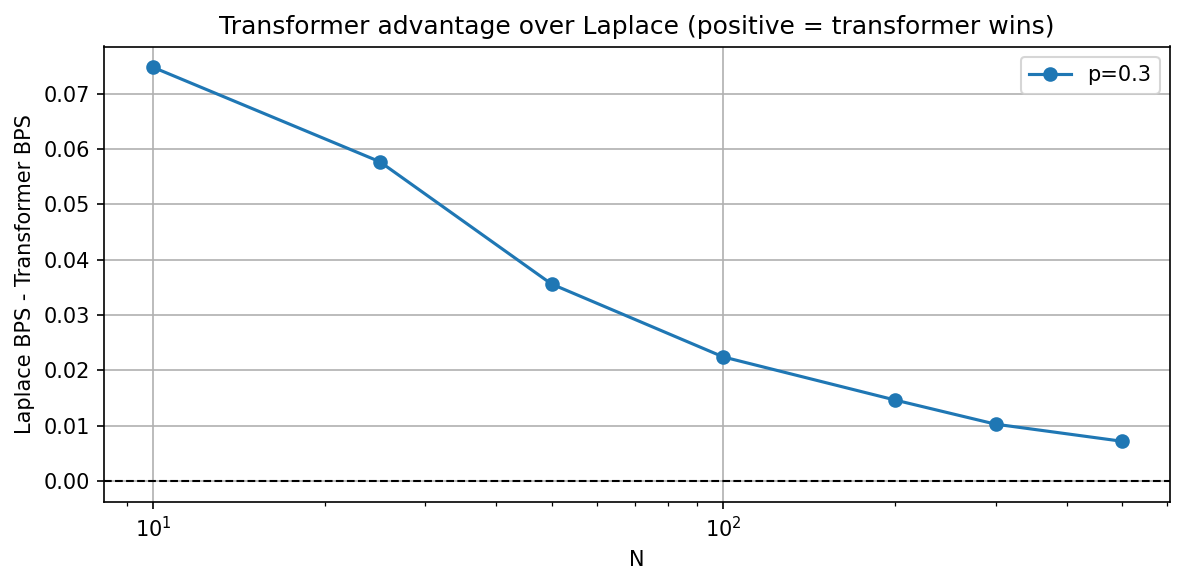

In [33]:
p03_results = load_experiment('p03_experiment.pkl')
print(p03_results)
p_values = [0.3]
N_values = sorted(next(iter(p03_results.values())).keys())
plot_bps_per_p(p03_results, p_values, N_values)
plot_gap(p03_results, p_values, N_values)

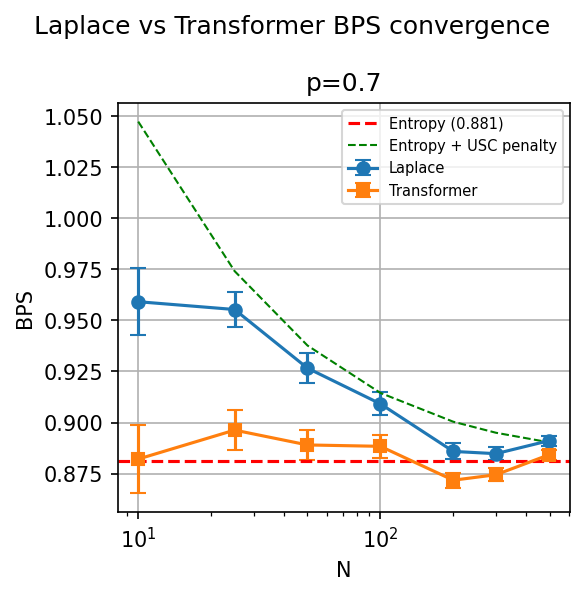

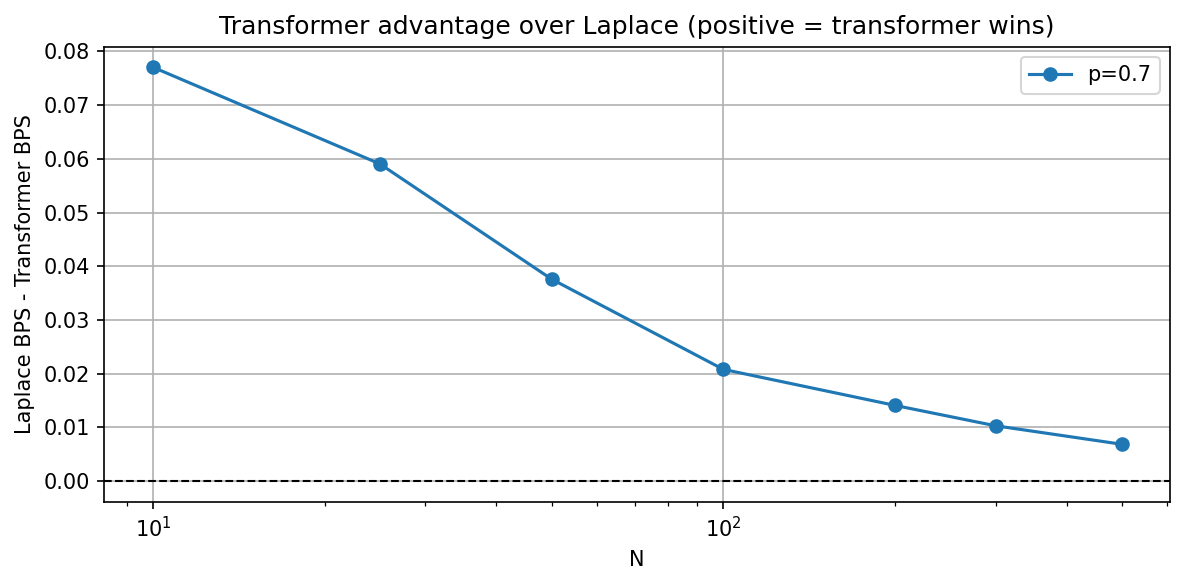

In [34]:
p07_results = load_experiment('p07_experiment.pkl')
p_values = [0.7]
N_values = sorted(next(iter(p07_results.values())).keys())
plot_bps_per_p(p07_results, p_values, N_values)
plot_gap(p07_results, p_values, N_values)

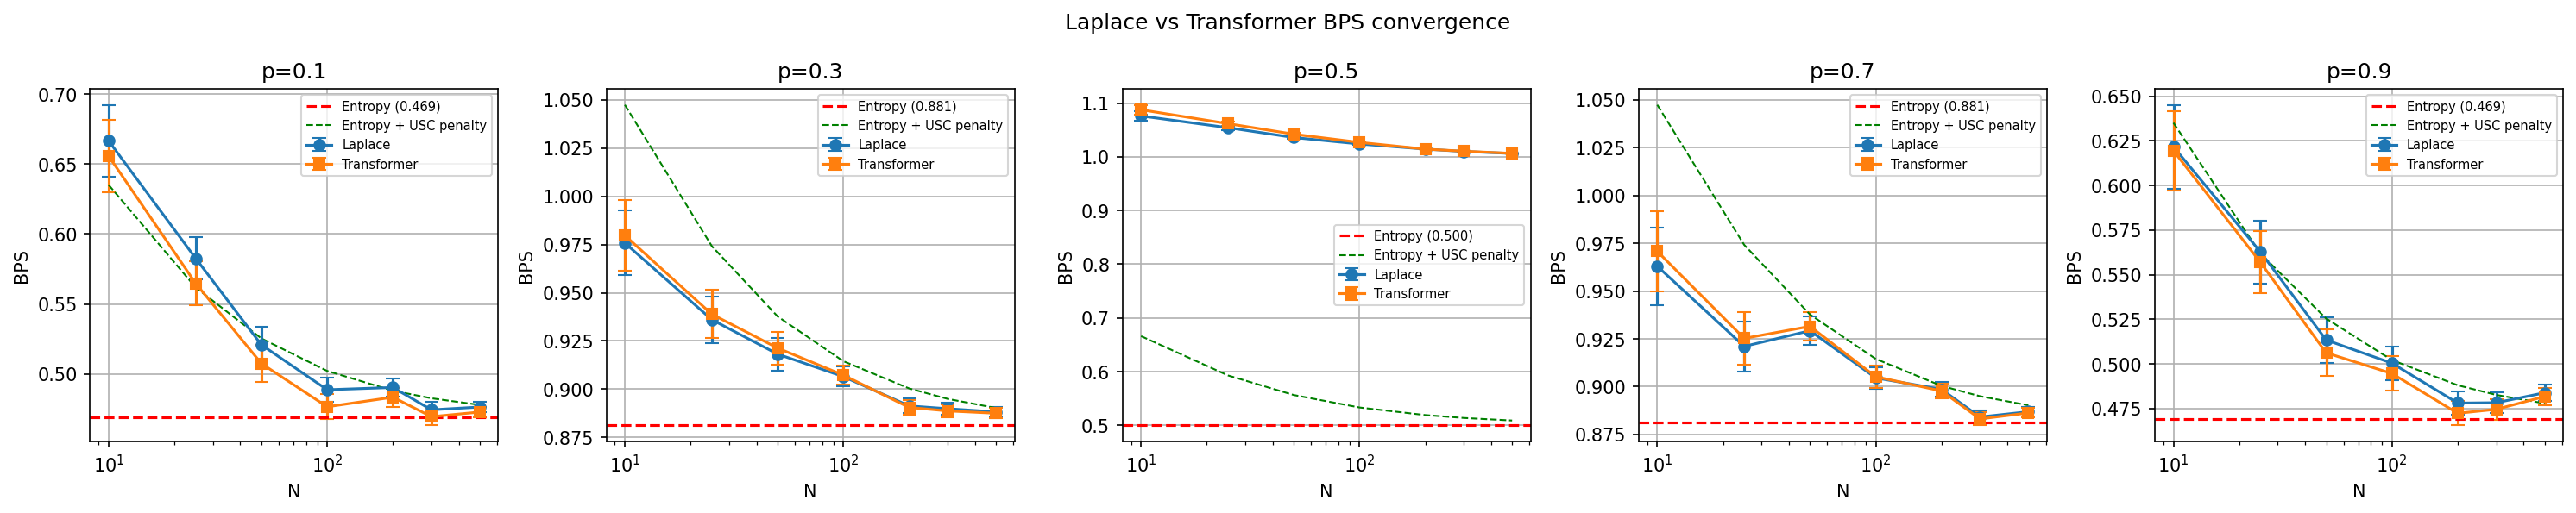

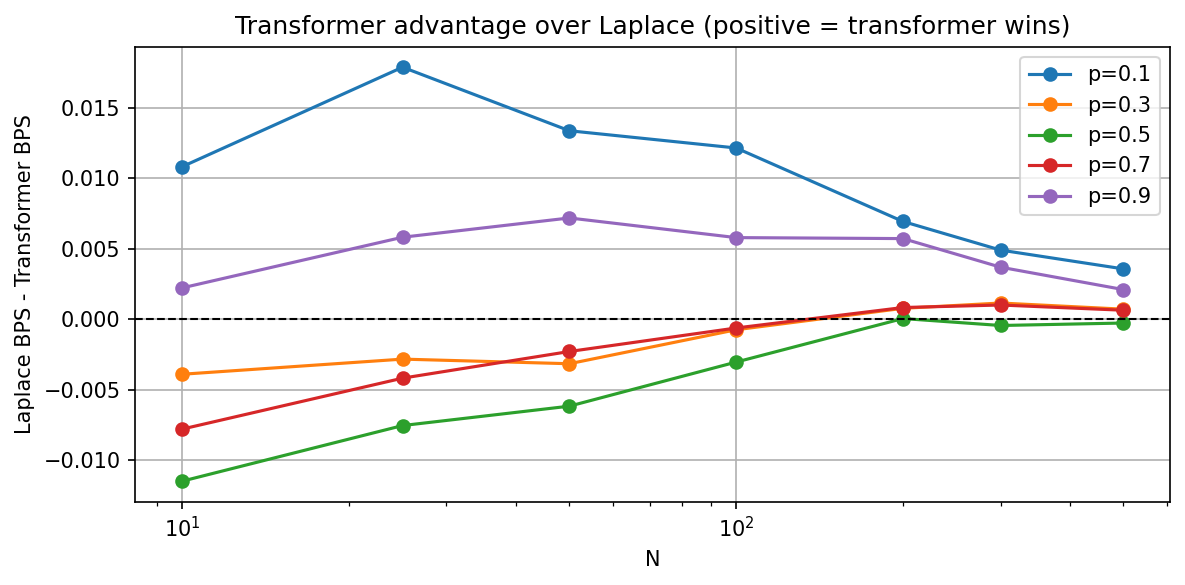

In [35]:
points_results = load_experiment('points_experiment.pkl')
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
plot_bps_per_p(points_results, p_values, N_values)
plot_gap(points_results, p_values, N_values)

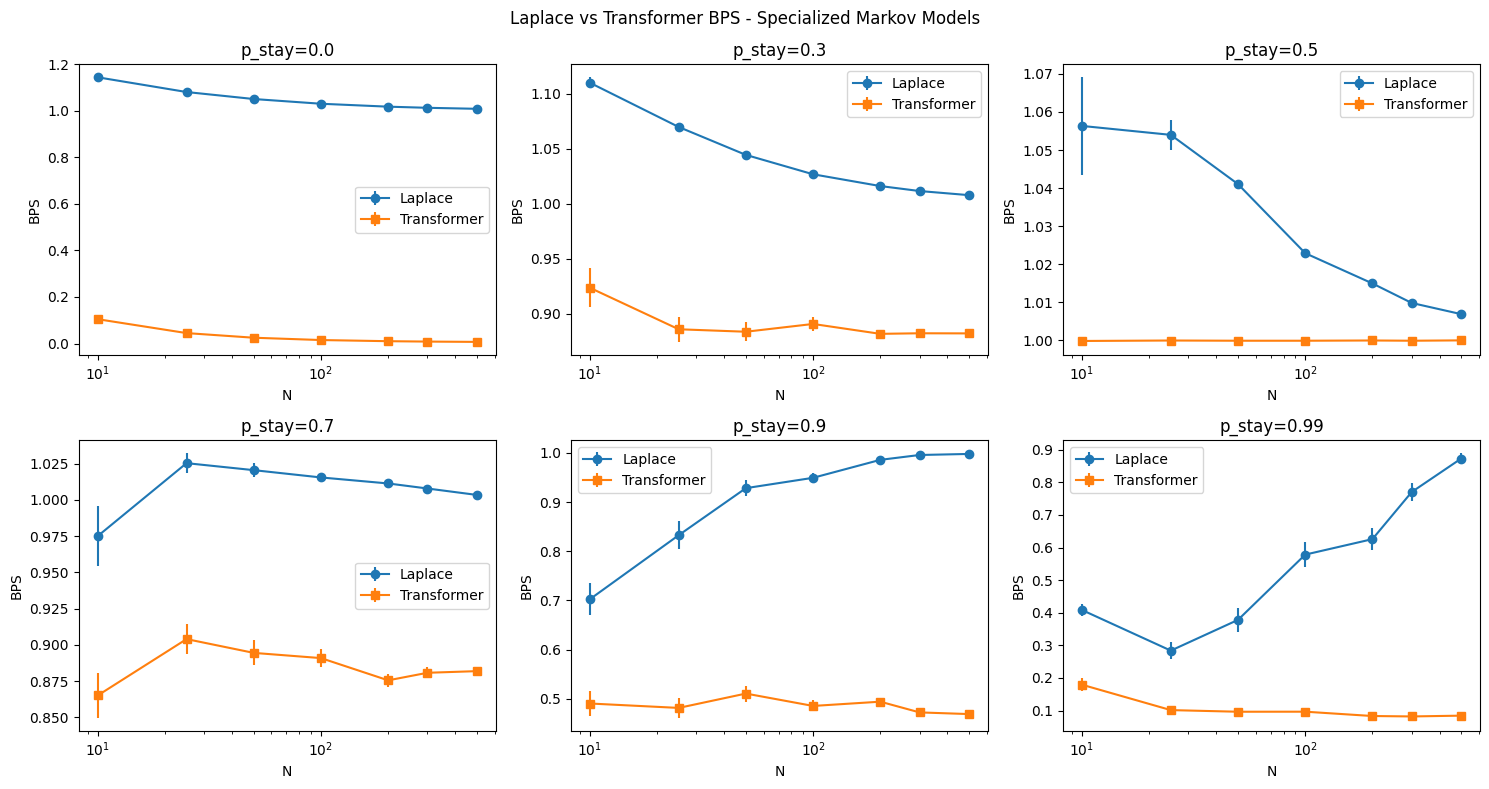

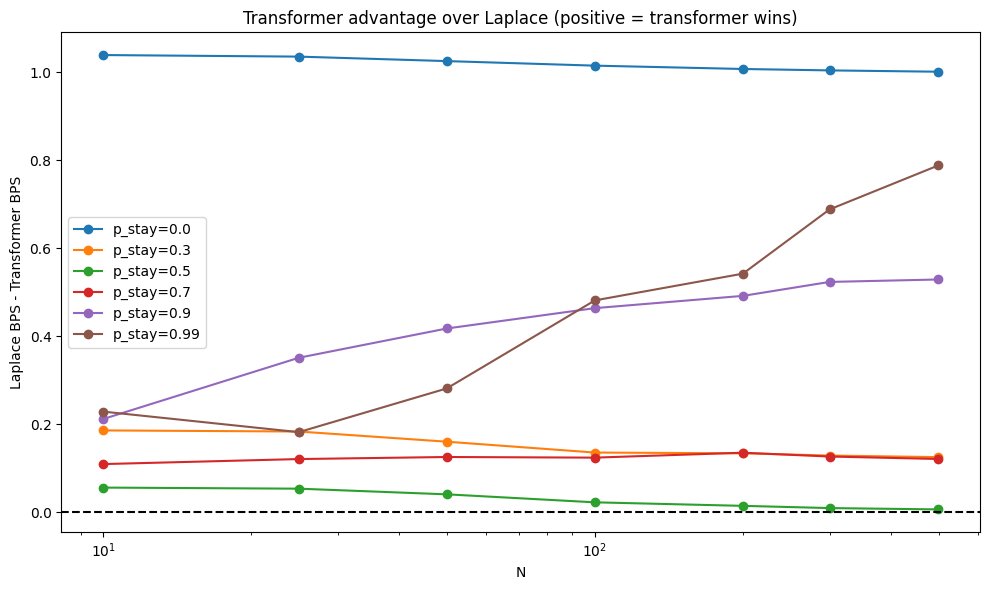

In [39]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

p_stay_sweep = [0.0, 0.3, 0.5, 0.7, 0.9, 0.99]
N_values = [10, 25, 50, 100, 200, 300, 499]

# Load all experiments
all_data = {}
for p_stay in p_stay_sweep:
    with open(f'../experiments/markov_{p_stay}_experiment.pkl', 'rb') as f:
        all_data[p_stay] = pickle.load(f)

# Plot 1: Grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, p_stay in enumerate(p_stay_sweep):
    ax = axes[idx]
    data = all_data[p_stay][p_stay]  # keyed by p_stay
    
    laplace_means = [data[N]['laplace'][0] for N in N_values]
    transformer_means = [data[N]['transformer'][0] for N in N_values]
    n_trials = 100
    laplace_stds = [data[N]['laplace'][1] / np.sqrt(n_trials) for N in N_values]
    transformer_stds = [data[N]['transformer'][1] / np.sqrt(n_trials) for N in N_values]
    
    ax.errorbar(N_values, laplace_means, yerr=laplace_stds, label='Laplace', marker='o')
    ax.errorbar(N_values, transformer_means, yerr=transformer_stds, label='Transformer', marker='s')
    ax.set_xscale('log')
    ax.set_title(f'p_stay={p_stay}')
    ax.set_xlabel('N')
    ax.set_ylabel('BPS')
    ax.legend()

plt.suptitle('Laplace vs Transformer BPS - Specialized Markov Models')
plt.tight_layout()
plt.show()

# Plot 2: Advantage plot
fig, ax = plt.subplots(figsize=(10, 6))

for p_stay in p_stay_sweep:
    data = all_data[p_stay][p_stay]
    advantage = [data[N]['laplace'][0] - data[N]['transformer'][0] for N in N_values]
    ax.plot(N_values, advantage, marker='o', label=f'p_stay={p_stay}')

ax.axhline(y=0, color='black', linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('Laplace BPS - Transformer BPS')
ax.set_title('Transformer advantage over Laplace (positive = transformer wins)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
alpha_sweep = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
N_values = [10, 25, 50, 100, 200, 300, 499]

all_data = {}
for alpha in alpha_sweep:
    with open(f'../experiments/fsm_{alpha}_experiment.pkl', 'rb') as f:
        all_data[alpha] = pickle.load(f)

# Plot 1: Grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, alpha in enumerate(alpha_sweep):
    ax = axes[idx]
    data = all_data[alpha][alpha]
    n_trials = 100

    laplace_means = [data[N]['laplace'][0] for N in N_values]
    transformer_means = [data[N]['transformer'][0] for N in N_values]
    ctw_means = [data[N]['ctw'][0] for N in N_values]

    laplace_stds = [data[N]['laplace'][1] / np.sqrt(n_trials) for N in N_values]
    transformer_stds = [data[N]['transformer'][1] / np.sqrt(n_trials) for N in N_values]
    ctw_stds = [data[N]['ctw'][1] / np.sqrt(n_trials) for N in N_values]

    ax.errorbar(N_values, laplace_means, yerr=laplace_stds, label='Laplace', marker='o')
    ax.errorbar(N_values, transformer_means, yerr=transformer_stds, label='Transformer', marker='s')
    ax.errorbar(N_values, ctw_means, yerr=ctw_stds, label='CTW', marker='^')
    ax.set_xscale('log')
    ax.set_title(f'alpha={alpha}')
    ax.set_xlabel('N')
    ax.set_ylabel('BPS')
    ax.legend()

plt.suptitle('Laplace vs Transformer vs CTW BPS - FSM Sweep')
plt.tight_layout()
plt.show()

# Plot 2: Advantage plot
fig, ax = plt.subplots(figsize=(10, 6))

for alpha in alpha_sweep:
    data = all_data[alpha][alpha]
    laplace_advantage = [data[N]['laplace'][0] - data[N]['transformer'][0] for N in N_values]
    ctw_advantage = [data[N]['ctw'][0] - data[N]['transformer'][0] for N in N_values]
    ax.plot(N_values, laplace_advantage, marker='o', label=f'Laplace-Transformer α={alpha}')
    ax.plot(N_values, ctw_advantage, marker='^', linestyle='--', label=f'CTW-Transformer α={alpha}')

ax.axhline(y=0, color='black', linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('Other BPS - Transformer BPS')
ax.set_title('Transformer advantage (positive = transformer wins)')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()